In [4]:
from __future__ import annotations

import operator
import os
import re
from datetime import date, timedelta
from typing import TypedDict, List, Annotated, Literal, Optional
from pathlib import Path

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

from dotenv import load_dotenv

load_dotenv()

/tmp/ipykernel_6130/2109465977.py:16: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


True

In [5]:
class Task(BaseModel):

    id : int
    title : str

    goal : str = Field(
        ...,
        description = "One sentence describing what the reader should be able to do/understand after this section"
    )

    bullets : List[str] = Field(
        ...,
        min_length = 3,
        max_length = 6,
        description = "3 - 6 concrete, non-overlapping subpoints to cover in this section"
    )

    target_words : int = Field(
        ...,
        description = "Target word count for this section (120 - 550)"
    )

    tags : List[str] = Field(default_factory = list)
    requires_research : bool = False
    requires_citations : bool = False
    requires_code : bool = False

In [6]:
class Plan(BaseModel):

    blog_title : str
    audience : str
    tone : str
    blog_kind : Literal["explainer", "tutorial", "news-roundup", "comparison", "system_design"] = "explainer"
    constraints : List[str] = Field(default_factory = list)
    tasks : List[Task]

In [7]:
class EvidenceItem(BaseModel):

    title : str
    url : str
    published_at : Optional[str] = None
    snippet : Optional[str] = None
    source : Optional[str] = None

class RouterDecision(BaseModel):

    needs_research : bool
    mode : Literal["closed_book", "hybrid", "open_book"]
    queries : List[str] = Field(default_factory = list)

class EvidencePack(BaseModel):

    evidence : List[EvidenceItem] = Field(default_factory = list)

In [8]:
class ImageSpec(BaseModel):

    placeholder : str = Field(..., description = "e.g. [[IMAGE_1]]")
    filename : str = Field(..., description = "Save under images/, e.g. qkv_flow.png")
    alt : str
    caption : str
    prompt : str = Field(..., description = "Prompt to send to the image model")
    size : Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality : Literal["low", "medium", "high"] = "medium"

class GlobalImagePlan(BaseModel):

    md_with_placeholders : str
    images :  List[ImageSpec] = Field(default_factory=list)

In [9]:
class State(TypedDict):

    topic : str
    mode : str
    needs_research : bool
    queries : List[str]
    evidence : List[EvidenceItem]
    plan : Optional[Plan]
    as_of : str
    recency_days : int
    sections : Annotated[List[tuple[int, str]], operator.add]
    merged_md : str
    md_with_placeholders : str
    image_specs : List[dict]
    final : str

In [160]:
llm = ChatGroq(
    model = "llama-3.3-70b-versatile"
)

In [161]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3-10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state : State) -> dict:

    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content = ROUTER_SYSTEM),
            HumanMessage(content = f"Topic : {topic}")
        ]
    )

    return {
        "needs_research" : decision.needs_research,
        "mode" : decision.mode,
        "queries" : decision.queries
    }

def route_next(state : State) -> str:

    return "research" if state["needs_research"] else "orchestrator"

In [162]:
def _tavily_search(query : str, max_results : int = 5) -> List[dict]:

    tool = TavilySearchResults(max_results = max_results)
    results = tool.invoke({
        "query" : query
    })

    normalized : List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title" : r.get("title") or "",
                "url" : r.get("url") or "",
                "snippet" : r.get("content") or r.get("snippet") or "",
                "published_at" : r.get("published_date" or r.get("published_at")),
                "source" : r.get("source")
            }
        )

    return normalized

RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def researcher_node(state : State) -> dict:

    queries = state.get("queries", []) or []
    max_results = 6

    raw_results : List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results = max_results))

    if not raw_results:
        return {"evidence" : []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content = RESEARCH_SYSTEM),
            HumanMessage(content = f"Raw results : \n{raw_results}")
        ]
    )

    dedup = {}
    for e in pack.evidence:

        if e.url:
            dedup[e.url] = e

    return {"evidence" : list(dedup.values())}

    

In [163]:
ORCH_SYSTEM = """
                You are a senior technical writer and developer advocate. Your job is to produce a highly actionable outline for a technical blog post."

                    "Hard requirements:\n"
                    "- Create 5-7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "2) 3-5 bullets that are concrete, specific, and non-overlapping\n"
                    "3) target word count (120-450)\n"

                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"

                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', 'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "* a minimal working example (MWE) or code sketch\n"
                    "* edge cases / failure modes\n"
                    "* performance/cost considerations\n"
                    "* security/privacy considerations (if relevant)\n"
                    "* debugging tips / observability (logs, metrics, traces)\n"

                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what to build/compare/measure/verify.\n\n"

                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build fundamentals before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema"
            """

def orchestrator_node(state : State) -> dict:

    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")
    
    plan = planner.invoke(
        [
            SystemMessage(content = ORCH_SYSTEM),
            HumanMessage(
                content = (
                    f"Topic : {state["topic"]}\n"
                    f"Mode : {mode}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty) : \n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            )
        ]
    )

    return {
        "plan" : plan
    }

In [164]:
def fanout(state : State):

    return [Send("worker", {
        "task" : task.model_dump(),
        "topic" : state["topic"],
        "mode" : state["mode"],
        "plan" : state["plan"].model_dump(),
        "evidence" : [e.model_dump() for e in state.get("evidence", [])]
    })
    for task in state["plan"].tasks]

In [165]:
WORKER_SYSTEM = """
You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URL.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

def worker_node(payload : dict) -> dict:

    task = Task(**payload["task"])
    topic = payload["topic"]
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or "date:unknown"}".strip()
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [
            SystemMessage(content = WORKER_SYSTEM),
            HumanMessage(
                content = (
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            )
        ]
    ).content.strip()

    return {"sections" : [(task.id, section_md)]}

In [ ]:
def merge_content(state : State) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key = lambda x : x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"

    return {"merged_md" : merged_md}

DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
Return strictly GlobalImagePlan.
"""

In [166]:
def reducer_node(state : State) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key = lambda x : x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final" : final_md}

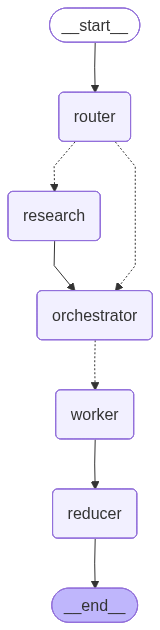

In [167]:
g = StateGraph(State)

g.add_node("router", router_node)
g.add_node("research", researcher_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {
    "research" : "research",
    "orchestrator" : "orchestrator"
})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [168]:
def run(topic : str):

    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [169]:
run("Write a blog on self attention")

/tmp/ipykernel_451086/2618604000.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results = max_results)


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.3-70b-versatile` in organization `org_01kpr33641ezfrhyr5d2pzzp1z` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Requested 14036, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}